# AIMLCZG546 - Software Engineering for Machine Learning
## Assignment I

# AI-Powered Resume Screening and Job Role Prediction System

This notebook implements a machine learning based resume screening application. The system classifies resumes into suitable job categories using natural language processing and supervised machine learning.

## Group Details

Group No: <Fill Group No>

| Sl. No | BITS ID | Name | Contribution | Percentage |
|---|---|---|---|---|
| 1 | 2024ac05325@wilp.bits-pilani.ac.in | Haridass K | Problem formulation, ML model development, system architecture, report preparation | 100% |
| 2 | 2024ac05104@wilp.bits-pilani.ac.in| SATHISH T .|Requirements formulation and GR4ML Business View | 100% |
| 3 | 2024ac05651@wilp.bits-pilani.ac.in| TEJAAL M .|Data preparation and Analytics Design View | 100% |
| 4 | 2024ac05728@wilp.bits-pilani.ac.in|SANJAYAN S .|Prototype testing, screenshots, and documentation | 100% |

In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("../data/Resume.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Stage 1: Data Understanding

This stage explores the resume dataset to understand its structure, identify the available features, verify data quality, and examine the distribution of job categories before preprocessing.

In [3]:
# Dataset Information
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nUnique Job Categories:", df["Category"].nunique())

print("\nCategory Distribution:")
print(df["Category"].value_counts())

Dataset Shape: (2484, 4)

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Data Types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Duplicate Records: 0

Unique Job Categories: 24

Category Distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA             

In [4]:
# Display sample resumes
df[["Category", "Resume_str"]].head()

,Category,Resume_str
0,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,HR,"HR SPECIALIST, US HR OPERATIONS ..."
2,HR,HR DIRECTOR Summary Over 2...
3,HR,HR SPECIALIST Summary Dedica...
4,HR,HR MANAGER Skill Highlights ...


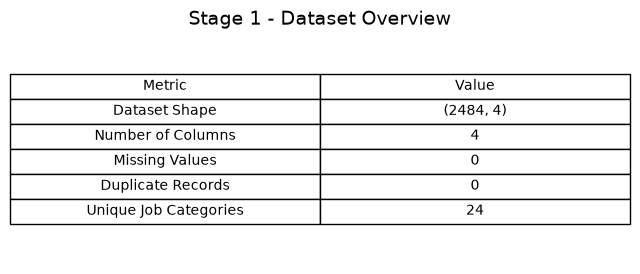

Screenshot saved: screenshots/stage1_dataset_overview.png


In [5]:
import matplotlib.pyplot as plt
import os

os.makedirs("../screenshots", exist_ok=True)

# Prepare dataset overview summary
summary_data = {
    "Metric": [
        "Dataset Shape",
        "Number of Columns",
        "Missing Values",
        "Duplicate Records",
        "Unique Job Categories"
    ],
    "Value": [
        str(df.shape),
        len(df.columns),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        df["Category"].nunique()
    ]
}

summary_df = pd.DataFrame(summary_data)

# Save summary as image
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Stage 1 - Dataset Overview", fontsize=14)
plt.savefig("../screenshots/stage1_dataset_overview.png", bbox_inches="tight", dpi=300)
plt.show()

print("Screenshot saved: screenshots/stage1_dataset_overview.png")

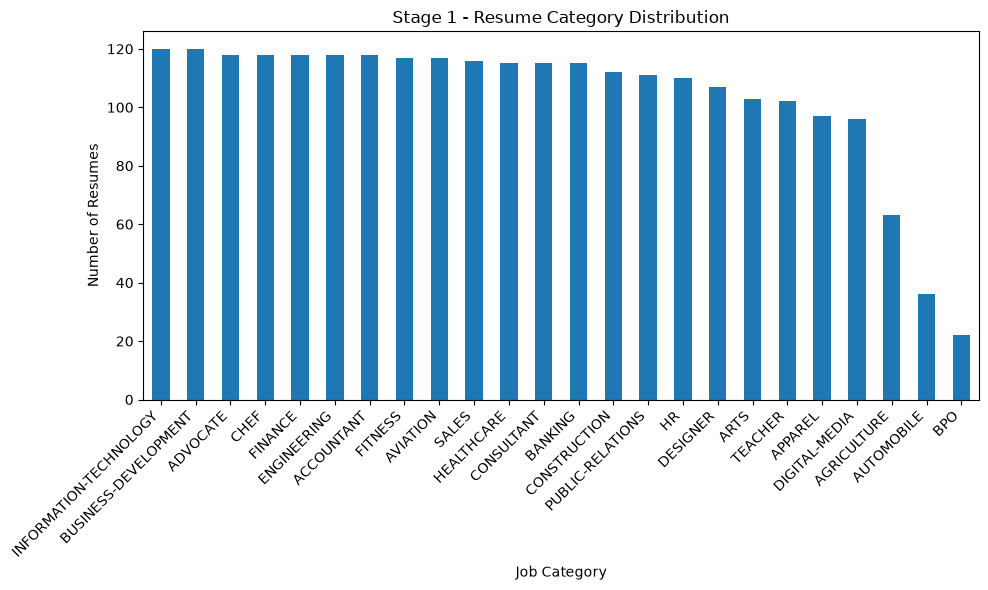

Screenshot saved: screenshots/stage1_category_distribution.png


In [6]:
# Save category distribution chart
category_counts = df["Category"].value_counts()

plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar")
plt.title("Stage 1 - Resume Category Distribution")
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../screenshots/stage1_category_distribution.png", dpi=300)
plt.show()

print("Screenshot saved: screenshots/stage1_category_distribution.png")

# Stage 2: Data Preprocessing

This stage prepares the resume text for machine learning by cleaning unnecessary characters, removing URLs, punctuation, numbers, and converting all text into lowercase. The cleaned text will be used for feature extraction using TF-IDF.

In [7]:
import re
import string

In [8]:
def clean_resume(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Convert to lowercase
    text = text.lower().strip()

    return text

In [9]:
df["Clean_Resume"] = df["Resume_str"].apply(clean_resume)

print("Resume cleaning completed successfully.")

df[["Category", "Clean_Resume"]].head()

Resume cleaning completed successfully.


,Category,Clean_Resume
0,HR,hr administratormarketing associate hr adminis...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary over years experience in r...
3,HR,hr specialist summary dedicated driven and dyn...
4,HR,hr manager skill highlights hr skills hr depar...


In [10]:
print("Original Resume:\n")
print(df["Resume_str"].iloc[0][:700])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df["Clean_Resume"].iloc[0][:700])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General 


Cleaned Resume:

hr administratormarketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customerfocused teams strives to instill a shared enthusiastic

C:\Users\Haridass\AppData\Local\Temp\ipykernel_28072\3515146168.py:20: UserWarning: Glyph 65293 (\N{FULLWIDTH HYPHEN-MINUS}) missing from font(s) DejaVu Sans.
  plt.savefig("../screenshots/stage2_preprocessing.png",
c:\Users\Haridass\anaconda3\envs\resume-screening\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65293 (\N{FULLWIDTH HYPHEN-MINUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


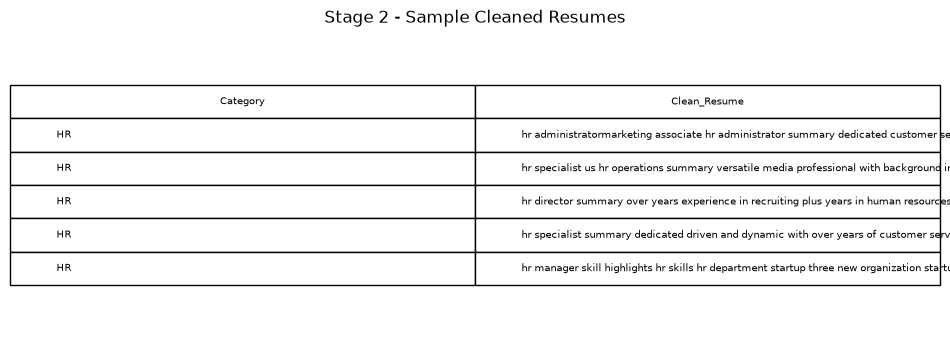

Saved: screenshots/stage2_preprocessing.png


In [11]:
# Save preprocessing sample as image
sample_df = df[["Category", "Clean_Resume"]].head(5)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

table = ax.table(
    cellText=sample_df.values,
    colLabels=sample_df.columns,
    cellLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 2)

plt.title("Stage 2 - Sample Cleaned Resumes")

plt.savefig("../screenshots/stage2_preprocessing.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("Saved: screenshots/stage2_preprocessing.png")

# Stage 3: Feature Engineering and Model Development

In this stage, the cleaned resume text is transformed into numerical feature vectors using the **Term Frequency–Inverse Document Frequency (TF-IDF)** technique. TF-IDF assigns higher importance to informative words while reducing the influence of commonly occurring terms, making the resume text suitable for machine learning classification.

The dataset is then divided into training and testing subsets using an 80:20 split. Multiple machine learning models are trained and evaluated to identify the most suitable model for resume classification.

The models implemented in this stage are:

- Logistic Regression
- Linear Support Vector Machine (Linear SVM)
- Random Forest Classifier
- Multinomial Naïve Bayes

Each model is evaluated using classification metrics such as accuracy, precision, recall, and F1-score. The best-performing model is selected based on the evaluation results and saved for deployment in the Resume Screening application.

In [13]:
X = df["Clean_Resume"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 1987
Testing records: 497


In [16]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=3),
    "Linear SVM": LinearSVC(C=1.0),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Naive Bayes": MultinomialNB()
}

results = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=15000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = {
        "pipeline": pipeline,
        "accuracy": accuracy,
        "predictions": y_pred
    }
    
    print("=" * 80)
    print(model_name)
    print("Accuracy:", round(accuracy, 4))
    print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
Accuracy: 0.6881
                        precision    recall  f1-score   support

            ACCOUNTANT       0.69      0.83      0.75        24
              ADVOCATE       0.45      0.62      0.53        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.50      0.21      0.30        19
                  ARTS       0.53      0.43      0.47        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.89      0.71      0.79        24
               BANKING       0.77      0.74      0.76        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.61      0.92      0.73        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.81      0.77      0.79        22
            CONSULTANT       0.57      0.35      0.43        23
              DESIGNER       0.85      0.81      0.83        21
  

In [17]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results.keys()]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.688129
1,Linear SVM,0.726358
2,Random Forest,0.758551
3,Naive Bayes,0.545272


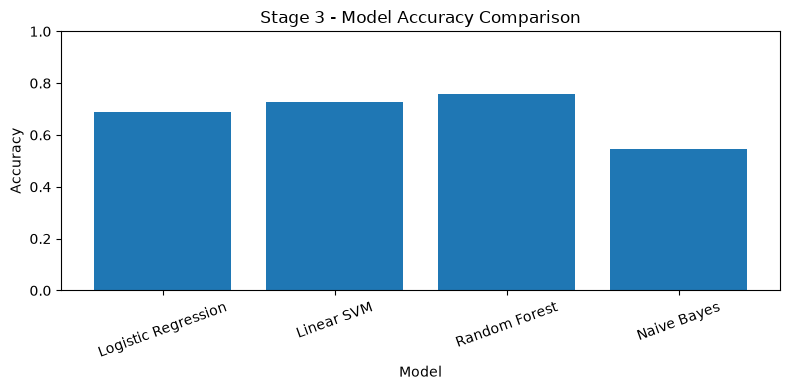

Saved: screenshots/stage3_model_comparison.png


In [18]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Stage 3 - Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../screenshots/stage3_model_comparison.png", dpi=300)
plt.show()

print("Saved: screenshots/stage3_model_comparison.png")

# Stage 4: Model Evaluation and Best Model Selection

This stage compares the performance of all trained machine learning models to identify the most suitable model for resume classification. The evaluation is based on accuracy and detailed classification metrics.

The best-performing model is selected and saved for deployment in the Resume Screening application. Saving the trained model enables it to be reused during inference without retraining, improving the efficiency of the deployed system.

In [20]:
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [round(results[m]["accuracy"], 4) for m in results]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy
0,Random Forest,0.7586
1,Linear SVM,0.7264
2,Logistic Regression,0.6881
3,Naive Bayes,0.5453


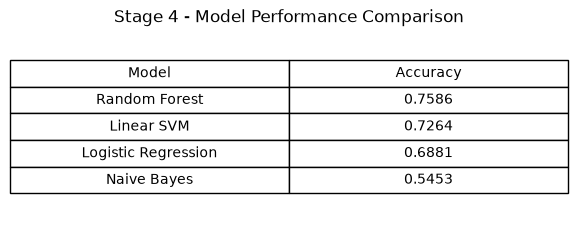

Saved: screenshots/stage4_model_comparison_table.png


In [21]:
fig, ax = plt.subplots(figsize=(6,2.5))
ax.axis("off")

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.6)

plt.title("Stage 4 - Model Performance Comparison")

plt.savefig(
    "../screenshots/stage4_model_comparison_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: screenshots/stage4_model_comparison_table.png")

In [22]:
best_model_name = comparison_df.iloc[0]["Model"]

best_model = results[best_model_name]["pipeline"]

print("Best Model Selected :", best_model_name)

print("Accuracy :", comparison_df.iloc[0]["Accuracy"])

Best Model Selected : Random Forest
Accuracy : 0.7586


In [23]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/resume_screening_model.pkl"

joblib.dump(best_model, model_path)

print("Model saved successfully.")

print(model_path)

Model saved successfully.
../models/resume_screening_model.pkl


In [24]:
loaded_model = joblib.load(model_path)

print("Saved model loaded successfully.")

sample_resume = X_test.iloc[0]

prediction = loaded_model.predict([sample_resume])

print("\nPredicted Category :", prediction[0])

print("\nActual Category :", y_test.iloc[0])

Saved model loaded successfully.

Predicted Category : DESIGNER

Actual Category : DESIGNER


# Stage 6: GR4ML Business View

## Business Problem

Recruitment teams receive hundreds of resumes for every job opening. Manual resume screening is time-consuming, inconsistent, and may overlook qualified candidates.

## Proposed Solution

Develop an AI-powered Resume Screening and Job Role Prediction System that automatically analyzes resume content and predicts the most suitable job category using machine learning.

## Stakeholders

- Job Applicants
- Human Resource (HR) Department
- Recruitment Team
- Hiring Managers
- System Administrator

## Business Objectives

- Reduce manual resume screening effort.
- Improve candidate shortlisting efficiency.
- Ensure consistent resume evaluation.
- Support faster recruitment decisions.

## Success Criteria

- Resume classification accuracy above 70%.
- Fast prediction response.
- Easy-to-use user interface.
- Reliable prediction history management.

# GR4ML Analytics Design View

## Machine Learning Task

Multi-class Text Classification

## Input

Resume Text

## Output

Predicted Job Category

## Machine Learning Pipeline

Resume Text
↓

Text Cleaning

↓

TF-IDF Feature Extraction

↓

Machine Learning Model

↓

Predicted Job Category

## Algorithms Evaluated

- Logistic Regression
- Linear SVM
- Random Forest
- Multinomial Naïve Bayes

## Selected Model

Random Forest Classifier

# GR4ML Data Preparation View

## Dataset

Resume Dataset (CSV)

## Data Preparation Activities

- Load dataset
- Remove unwanted characters
- Remove URLs
- Remove email addresses
- Remove numbers
- Convert text to lowercase
- Remove punctuation
- Generate cleaned resume text

## Feature Engineering

TF-IDF Vectorization

## Dataset Split

Training Data : 80%

Testing Data : 20%

# Quality Requirements

## 1. Accuracy

The system should accurately classify resumes into appropriate job categories to assist recruiters.

## 2. Performance

The application should generate predictions within a few seconds after the resume is submitted.

## 3. Usability

The system should provide an intuitive interface allowing recruiters to perform resume screening without technical expertise.

# Stage 7: System Architecture and Architectural Patterns

This stage presents the architecture of the Resume Screening system. The system applies two architectural patterns from the Software Engineering for Machine Learning syllabus: Pipe-and-Filter Architecture and Monolithic Architecture.

## Pipe-and-Filter Architecture

The Resume Screening application follows the Pipe-and-Filter architectural pattern for the machine learning pipeline. Each processing stage performs a specific task and passes its output to the next stage.

Pipeline Flow:

Resume Input
↓

Text Cleaning
↓

TF-IDF Feature Extraction
↓

Machine Learning Model (Random Forest)
↓

Job Category Prediction
↓

Prediction Storage

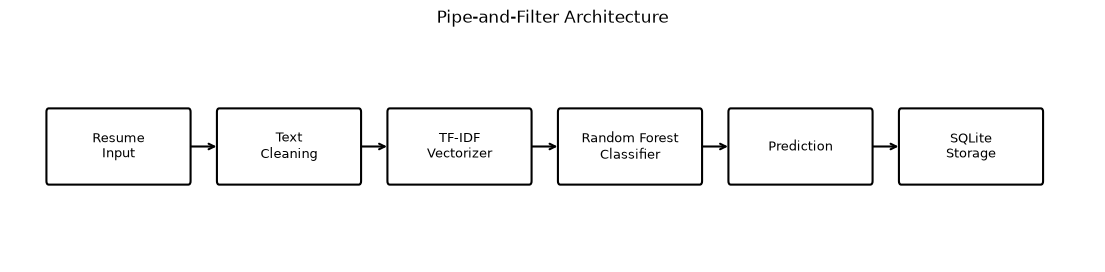

In [26]:
fig, ax = plt.subplots(figsize=(14,3))
ax.set_xlim(0,14)
ax.set_ylim(0,2)
ax.axis("off")

steps = [
    "Resume\nInput",
    "Text\nCleaning",
    "TF-IDF\nVectorizer",
    "Random Forest\nClassifier",
    "Prediction",
    "SQLite\nStorage"
]

x = 0.5

for step in steps:
    draw_box(ax, x, 0.7, 1.8, 0.6, step)
    x += 2.2

for i in range(5):
    arrow(ax,
          2.3 + (2.2*i),
          1.0,
          2.7 + (2.2*i),
          1.0)

plt.title("Pipe-and-Filter Architecture")

plt.savefig(
    "../screenshots/stage7_pipe_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Monolithic Architecture

The Resume Screening prototype is implemented as a monolithic application where all software components execute within a single deployable application.

Components included:

- Streamlit User Interface
- Resume Processing Module
- TF-IDF Feature Extraction
- Machine Learning Prediction Module
- SQLite Database
- Saved Machine Learning Model

Since the application is small and self-contained, a monolithic architecture simplifies deployment and maintenance.

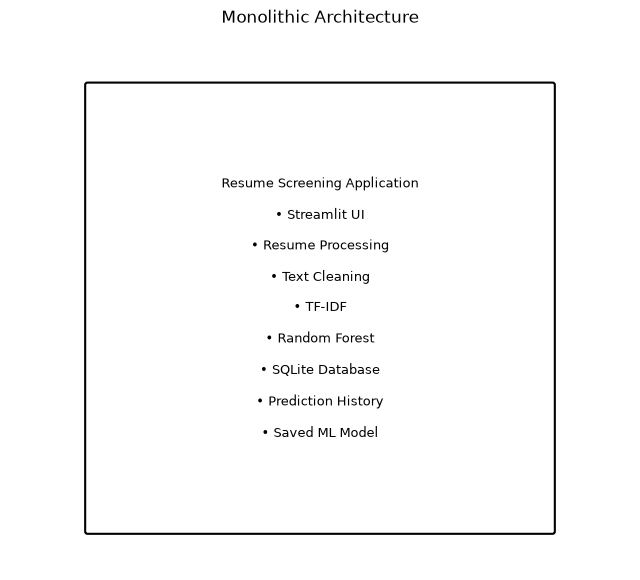

In [27]:
fig, ax = plt.subplots(figsize=(8,7))
ax.set_xlim(0,8)
ax.set_ylim(0,7)
ax.axis("off")

draw_box(ax,1,0.5,6,5.8,
"""
Resume Screening Application

• Streamlit UI

• Resume Processing

• Text Cleaning

• TF-IDF

• Random Forest

• SQLite Database

• Prediction History

• Saved ML Model
""")

plt.title("Monolithic Architecture")

plt.savefig(
    "../screenshots/stage7_monolithic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Command Query Responsibility Segregation (CQRS)

The Resume Screening application also applies a simple CQRS pattern by separating write operations and read operations.

Command Side:
- The `save_prediction()` function writes prediction results into the SQLite database.

Query Side:
- The `view_history()` function reads prediction history from the SQLite database.

This separation improves clarity because prediction saving and prediction history viewing are handled by separate functions.